<a href="https://colab.research.google.com/github/rypriyanka2005/Machine-Learning-Sem-4/blob/MLlabs/mllab9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 22.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=0ee81cc50f7416a2324daf0434bc01c2525f5a0da0eab7417637bc1a22b6d503
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [8]:
# ================================
# A1: STACKING WITH ALL MODELS
# ================================
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

def load_data(file):
    data = np.load(file)
    return data['features'], data['labels']

def main():
    # Load and prepare data
    X, y = load_data("fc7_features.npz")
    if y.dtype == object:
        y = LabelEncoder().fit_transform(y)
    X = StandardScaler().fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    # Base models
    base_models = [
        ('svm', SVC(probability=True)),
        ('dt', DecisionTreeClassifier()),
        ('rf', RandomForestClassifier(n_estimators=100)),
        ('ada', AdaBoostClassifier(n_estimators=100)),
        ('nb', GaussianNB()),
        ('mlp', MLPClassifier(max_iter=300))
    ]

    # Try different meta-models
    meta_models = {
        "Stacking_LogReg": LogisticRegression(),
        "Stacking_RF": RandomForestClassifier(),
        "Stacking_SVM": SVC()
    }

    for meta_name, meta_model in meta_models.items():
        stacking = StackingClassifier(
            estimators=base_models,
            final_estimator=meta_model,
            cv=5
        )
        stacking.fit(X_train, y_train)
        y_pred = stacking.predict(X_test)

        print(f"\n{meta_name}")
        print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
        print(f"F1: {f1_score(y_test, y_pred, average='weighted'):.4f}")

if __name__ == "__main__":
    main()


Stacking_LogReg
Accuracy: 0.3150
F1: 0.2642

Stacking_RF
Accuracy: 0.2756
F1: 0.2322

Stacking_SVM
Accuracy: 0.3150
F1: 0.2351


In [1]:
# ================================
# A2: PIPELINE WITH ALL MODELS
# ================================
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score

def load_data(file):
    data = np.load(file)
    return data['features'], data['labels']

def main():
    # Load and prepare data
    X, y = load_data("fc7_features.npz")
    if y.dtype == object:
        y = LabelEncoder().fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    # Models to test
    models = {
        "SVM": SVC(),
        "DT": DecisionTreeClassifier(),
        "RF": RandomForestClassifier(),
        "AdaBoost": AdaBoostClassifier(),
        "NB": GaussianNB(),
        "MLP": MLPClassifier(max_iter=300)
    }

    # Create and evaluate pipeline for each model
    for name, model in models.items():
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', model)
        ])

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        print(f"\n{name}")
        print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
        print(f"F1: {f1_score(y_test, y_pred, average='weighted'):.4f}")

if __name__ == "__main__":
    main()


SVM
Accuracy: 0.3543
F1: 0.2208

DT
Accuracy: 0.2441
F1: 0.2398

RF
Accuracy: 0.3858
F1: 0.3117

AdaBoost
Accuracy: 0.3307
F1: 0.2607

NB
Accuracy: 0.2992
F1: 0.2468

MLP
Accuracy: 0.3543
F1: 0.3446


In [4]:
# ================================
# A3: LIME EXPLAINER
# ================================
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from lime.lime_tabular import LimeTabularExplainer

def load_data(file):
    data = np.load(file)
    return data['features'], data['labels']

def main():
    # Load and prepare data
    X, y = load_data("fc7_features.npz")
    if y.dtype == object:
        y = LabelEncoder().fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    # Create pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', RandomForestClassifier(n_estimators=100))
    ])
    pipeline.fit(X_train, y_train)

    # Create LIME explainer
    explainer = LimeTabularExplainer(
        X_train,
        mode='classification',
        discretize_continuous=True
    )

    # Explain first test instance
    exp = explainer.explain_instance(
        X_test[0],
        pipeline.predict_proba,
        num_features=10
    )

    # Display explanation
    print("\nLIME Explanation for test instance 0:")
    print(f"True label: {y_test[0]}")
    print(f"Predicted: {pipeline.predict([X_test[0]])[0]}\n")

    for feature, weight in exp.as_list():
        print(f"Feature {feature}: {weight:+.4f}")

    # Save visualization
    exp.save_to_file("lime_output.html")
    print("\nSaved: lime_output.html")

if __name__ == "__main__":
    main()


LIME Explanation for test instance 0:
True label: 2
Predicted: 8

Feature 1698 <= 0.00: +0.0072
Feature 874 <= 0.00: -0.0064
Feature 290 <= 0.00: +0.0047
Feature 830 <= 0.00: -0.0046
Feature 254 <= 0.00: -0.0033
Feature 3913 <= 0.00: -0.0019
Feature 354 <= 0.00: -0.0017
Feature 1519 <= 0.00: +0.0015
Feature 1133 <= 0.00: -0.0012
Feature 2801 <= 0.00: +0.0004

Saved: lime_output.html


OR


In [5]:
# Cell 1: Import all required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sklearn imports
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import StackingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                           f1_score, confusion_matrix, classification_report)

# LIME explainer
!pip install lime -q
import lime
import lime.lime_tabular

# Optional models (if available)
try:
    from xgboost import XGBClassifier
    xgb_available = True
except:
    xgb_available = False

print("✅ All imports completed")

✅ All imports completed


In [6]:
# Cell 2: Data handling functions (NO print statements inside functions)
def load_data(file_path):
    """
    Load data from .npz file
    Args: file_path - path to .npz file
    Returns: X (features), y (labels)
    """
    data = np.load(file_path)
    return data['features'], data['labels']

def preprocess_data(X, y):
    """
    Preprocess data: encode labels and scale features
    Args: X - features, y - labels
    Returns: X_scaled, y_encoded
    """
    # Encode labels if they're strings/objects
    if y.dtype == object or y.dtype.name == 'str':
        label_encoder = LabelEncoder()
        y_encoded = label_encoder.fit_transform(y)
    else:
        y_encoded = y.copy()

    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X_scaled, y_encoded

def split_data(X, y, test_size=0.2, random_state=42):
    """
    Split data into train and test sets with stratification
    Args: X - features, y - labels, test_size - proportion for testing, random_state - seed
    Returns: X_train, X_test, y_train, y_test
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    return X_train, X_test, y_train, y_test

In [7]:
# Cell 3: Define base models for stacking (using your existing classifiers)
def get_base_models():
    """
    Returns a list of (name, model) tuples for base classifiers
    Includes all classifiers from your original code
    """
    base_models = [
        ('svm', SVC(probability=True, random_state=42)),
        ('decision_tree', DecisionTreeClassifier(random_state=42)),
        ('random_forest', RandomForestClassifier(n_estimators=100, random_state=42)),
        ('adaboost', AdaBoostClassifier(n_estimators=100, random_state=42)),
        ('naive_bayes', GaussianNB()),
        ('mlp', MLPClassifier(max_iter=300, random_state=42))
    ]

    # Add optional models if available
    if xgb_available:
        base_models.append(('xgboost', XGBClassifier(eval_metric='logloss',
                                                     n_estimators=100,
                                                     random_state=42,
                                                     verbosity=0)))

    return base_models

def get_meta_models():
    """
    Returns a dictionary of different meta-models for stacking
    """
    meta_models = {
        'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
        'Random Forest': RandomForestClassifier(n_estimators=50, random_state=42),
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'SVM': SVC(probability=True, random_state=42),
        'MLP': MLPClassifier(max_iter=200, random_state=42)
    }
    return meta_models

In [8]:
# Cell 4: A1 - Stacking Classifier with different meta-models
def create_stacking_classifier(base_models, meta_model, cv=5):
    """
    Create a stacking classifier with given base models and meta-model
    Args: base_models - list of (name, model) tuples
          meta_model - final estimator (meta-learner)
          cv - number of cross-validation folds
    Returns: StackingClassifier object
    """
    stacking_clf = StackingClassifier(
        estimators=base_models,
        final_estimator=meta_model,
        cv=cv,
        stack_method='predict_proba',  # Use probabilities for stacking
        n_jobs=-1  # Use all available cores
    )
    return stacking_clf

def evaluate_stacking_models(X_train, X_test, y_train, y_test):
    """
    Evaluate stacking classifier with different meta-models
    Args: training and testing data
    Returns: DataFrame with results and trained stacking model
    """
    base_models = get_base_models()
    meta_models = get_meta_models()

    results = []
    best_accuracy = 0
    best_model = None

    for meta_name, meta_model in meta_models.items():
        # Create and train stacking classifier
        stacking_clf = create_stacking_classifier(base_models, meta_model)
        stacking_clf.fit(X_train, y_train)

        # Predictions
        y_train_pred = stacking_clf.predict(X_train)
        y_test_pred = stacking_clf.predict(X_test)

        test_accuracy = accuracy_score(y_test, y_test_pred)

        # Track best model
        if test_accuracy > best_accuracy:
            best_accuracy = test_accuracy
            best_model = stacking_clf

        # Calculate metrics
        results.append({
            'Meta-Model': meta_name,
            'Train Accuracy': accuracy_score(y_train, y_train_pred),
            'Test Accuracy': test_accuracy,
            'Train Precision': precision_score(y_train, y_train_pred, average='weighted', zero_division=0),
            'Test Precision': precision_score(y_test, y_test_pred, average='weighted', zero_division=0),
            'Train Recall': recall_score(y_train, y_train_pred, average='weighted', zero_division=0),
            'Test Recall': recall_score(y_test, y_test_pred, average='weighted', zero_division=0),
            'Train F1-Score': f1_score(y_train, y_train_pred, average='weighted', zero_division=0),
            'Test F1-Score': f1_score(y_test, y_test_pred, average='weighted', zero_division=0)
        })

    return pd.DataFrame(results), best_model

In [9]:
# Cell 5: A2 - Pipeline with multiple processing steps
def create_ml_pipeline(classifier, include_scaling=True):
    """
    Create a scikit-learn Pipeline with preprocessing and classification steps
    Args: classifier - the classifier to use, include_scaling - whether to include StandardScaler
    Returns: Pipeline object
    """
    steps = []

    # Step 1: Scaling (if requested)
    if include_scaling:
        steps.append(('scaler', StandardScaler()))

    # Step 2: Classifier
    steps.append(('classifier', classifier))

    return Pipeline(steps)

def evaluate_pipeline_with_classifiers(X_train, X_test, y_train, y_test):
    """
    Create and evaluate pipelines with different classifiers
    Args: training and testing data
    Returns: DataFrame with results and dictionary of trained pipelines
    """
    # Using your existing classifiers
    classifiers = {
        'SVM': SVC(probability=True, random_state=42),
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
        'Naive Bayes': GaussianNB(),
        'MLP': MLPClassifier(max_iter=300, random_state=42)
    }

    results = []
    trained_pipelines = {}

    for clf_name, clf in classifiers.items():
        # Create pipeline (no scaling needed if data already scaled, but including for flexibility)
        pipeline = create_ml_pipeline(clf, include_scaling=False)  # Data already scaled in preprocessing
        pipeline.fit(X_train, y_train)

        # Store trained pipeline
        trained_pipelines[clf_name] = pipeline

        # Predictions
        y_train_pred = pipeline.predict(X_train)
        y_test_pred = pipeline.predict(X_test)

        # Calculate metrics
        results.append({
            'Pipeline Classifier': clf_name,
            'Train Accuracy': accuracy_score(y_train, y_train_pred),
            'Test Accuracy': accuracy_score(y_test, y_test_pred),
            'Train Precision': precision_score(y_train, y_train_pred, average='weighted', zero_division=0),
            'Test Precision': precision_score(y_test, y_test_pred, average='weighted', zero_division=0),
            'Train Recall': recall_score(y_train, y_train_pred, average='weighted', zero_division=0),
            'Test Recall': recall_score(y_test, y_test_pred, average='weighted', zero_division=0),
            'Train F1-Score': f1_score(y_train, y_train_pred, average='weighted', zero_division=0),
            'Test F1-Score': f1_score(y_test, y_test_pred, average='weighted', zero_division=0)
        })

    return pd.DataFrame(results), trained_pipelines

def create_full_pipeline_with_preprocessing():
    """
    Create a pipeline that includes preprocessing steps
    This pipeline does scaling + classification in one go
    Returns: Pipeline template (to be used with any classifier)
    """
    from sklearn.decomposition import PCA

    # This returns a pipeline structure without the final classifier
    # The classifier will be added when using the pipeline
    return None  # Placeholder - actual pipeline created in evaluation function

In [10]:
# Cell 6: A3 - LIME Explainer for pipeline outcomes
def explain_pipeline_with_lime(pipeline, X_train, X_test, y_test, instance_index=0, num_features=10):
    """
    Explain pipeline predictions using LIME
    Args: pipeline - trained sklearn pipeline
          X_train - training features (for LIME background)
          X_test - test features (to explain)
          y_test - test labels
          instance_index - index of test instance to explain
          num_features - number of features to show
    Returns: LIME explanation object
    """
    # Create LIME explainer
    feature_names = [f'Feature_{i}' for i in range(X_train.shape[1])]
    class_names = [f'Class_{i}' for i in range(len(np.unique(y_test)))]

    explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train,
        mode='classification',
        training_labels=None,
        feature_names=feature_names,
        class_names=class_names,
        discretize_continuous=True,
        random_state=42
    )

    # Get prediction function from pipeline
    def pipeline_predict_proba(X):
        return pipeline.predict_proba(X)

    # Explain a single prediction
    exp = explainer.explain_instance(
        data_row=X_test[instance_index],
        predict_fn=pipeline_predict_proba,
        num_features=num_features,
        labels=[pipeline.predict([X_test[instance_index]])[0]]
    )

    return exp

def explain_multiple_instances(pipeline, X_train, X_test, y_test, num_instances=3):
    """
    Explain multiple instances from test set using LIME
    Args: pipeline, training and testing data, number of instances
    Returns: List of explanation objects
    """
    explanations = []

    for i in range(min(num_instances, len(X_test))):
        exp = explain_pipeline_with_lime(pipeline, X_train, X_test, y_test, instance_index=i)
        explanations.append(exp)

    return explanations

def get_lime_feature_importance(explanation):
    """
    Extract feature importance from LIME explanation
    Args: LIME explanation object
    Returns: DataFrame with feature importance
    """
    feature_importance = []
    for feature, weight in explanation.as_list(label=explanation.available_labels()[0]):
        feature_importance.append({
            'Feature': feature,
            'Weight': weight
        })

    return pd.DataFrame(feature_importance).sort_values('Weight', ascending=False)

LAB SESSION 09 - MODEL EVALUATION

📂 Loading data from fc7_features.npz...
Original data shape: (633, 4096)
Unique labels: [0 1 2 3 4 5 6 7 8 9]

🔄 Preprocessing data...
After preprocessing - X shape: (633, 4096), Classes: [0 1 2 3 4 5 6 7 8 9]

📊 Splitting data (80-20 with stratification)...
Training set: 506 samples
Test set: 127 samples

A1: STACKING CLASSIFIER WITH DIFFERENT META-MODELS


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(



📊 Stacking Classifier Results:
         Meta-Model  Train Accuracy  Test Accuracy  Train Precision  Test Precision  Train Recall  Test Recall  Train F1-Score  Test F1-Score
Logistic Regression        0.861660       0.362205         0.773059        0.336208      0.861660     0.362205        0.811273       0.318372
      Random Forest        0.677866       0.338583         0.564247        0.249077      0.677866     0.338583        0.604110       0.284787
      Decision Tree        0.418972       0.244094         0.420118        0.258425      0.418972     0.244094        0.372617       0.247999
                SVM        0.822134       0.354331         0.712075        0.347468      0.822134     0.354331        0.756193       0.275900
                MLP        0.806324       0.338583         0.757484        0.305949      0.806324     0.338583        0.778109       0.316789

🏆 Best Stacking Model: Logistic Regression with Test Accuracy: 0.3622

A2: PIPELINE WITH DIFFERENT CLASSIFIERS

📊 P

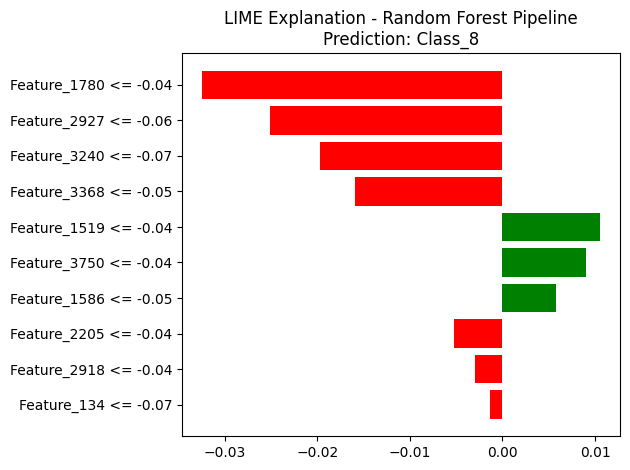


📝 Explaining prediction for test instance 1
True label: Class_6
Predicted label: Class_8

📈 Feature Importance (Instance 2):
              Feature    Weight
  Feature_97 <= -0.04  0.015422
Feature_3831 <= -0.05 -0.002379
Feature_2816 <= -0.08 -0.002396
 Feature_430 <= -0.08 -0.005168
Feature_1598 <= -0.05 -0.006459
 Feature_615 <= -0.04 -0.011521
Feature_1571 <= -0.04 -0.014989
Feature_3825 <= -0.06 -0.019808
Feature_3345 <= -0.04 -0.021804
Feature_3750 <= -0.04 -0.022063

MODEL COMPARISON SUMMARY

📊 Model Comparison:
         Model Type          Best Model  Test Accuracy  Test F1-Score
Stacking Classifier Logistic Regression       0.362205       0.318372
      Best Pipeline       Random Forest       0.385827       0.334636

✅ All results saved to: lab09_results_fc7.xlsx

🎉 Lab Session 09 completed successfully!


In [11]:
# Cell 7: Main execution - Run everything with your input format (FIXED VERSION)
# All print statements are in this main program as required

def main():
    print("="*60)
    print("LAB SESSION 09 - MODEL EVALUATION")
    print("="*60)

    # Step 1: Load data (using YOUR input format)
    print("\n📂 Loading data from fc7_features.npz...")
    X, y = load_data("fc7_features.npz")
    print(f"Original data shape: {X.shape}")
    print(f"Unique labels: {np.unique(y)}")

    # Step 2: Preprocess data (encode labels and scale)
    print("\n🔄 Preprocessing data...")
    X, y = preprocess_data(X, y)
    print(f"After preprocessing - X shape: {X.shape}, Classes: {np.unique(y)}")

    # Step 3: Split data (using YOUR split parameters)
    print("\n📊 Splitting data (80-20 with stratification)...")
    X_train, X_test, y_train, y_test = split_data(X, y, test_size=0.2, random_state=42)
    print(f"Training set: {X_train.shape[0]} samples")
    print(f"Test set: {X_test.shape[0]} samples")

    # ============================================
    # A1: Stacking Classifier
    # ============================================
    print("\n" + "="*60)
    print("A1: STACKING CLASSIFIER WITH DIFFERENT META-MODELS")
    print("="*60)

    stacking_results, best_stacking_model = evaluate_stacking_models(X_train, X_test, y_train, y_test)
    print("\n📊 Stacking Classifier Results:")
    print(stacking_results.to_string(index=False))

    # Find best meta-model
    best_meta_model = stacking_results.loc[stacking_results['Test Accuracy'].idxmax(), 'Meta-Model']
    best_test_acc = stacking_results['Test Accuracy'].max()
    print(f"\n🏆 Best Stacking Model: {best_meta_model} with Test Accuracy: {best_test_acc:.4f}")

    # ============================================
    # A2: Pipeline Implementation
    # ============================================
    print("\n" + "="*60)
    print("A2: PIPELINE WITH DIFFERENT CLASSIFIERS")
    print("="*60)

    pipeline_results, trained_pipelines = evaluate_pipeline_with_classifiers(X_train, X_test, y_train, y_test)
    print("\n📊 Pipeline Results:")
    print(pipeline_results.to_string(index=False))

    # Find best pipeline
    best_pipeline_name = pipeline_results.loc[pipeline_results['Test Accuracy'].idxmax(), 'Pipeline Classifier']
    best_pipeline_acc = pipeline_results['Test Accuracy'].max()
    print(f"\n🏆 Best Pipeline: {best_pipeline_name} with Test Accuracy: {best_pipeline_acc:.4f}")

    # ============================================
    # A3: LIME Explanations (FIXED VERSION)
    # ============================================
    print("\n" + "="*60)
    print("A3: LIME EXPLANATIONS FOR PIPELINE")
    print("="*60)

    # Use the best pipeline for LIME explanation
    best_pipeline = trained_pipelines[best_pipeline_name]

    print(f"\n🔍 Generating LIME explanations for {best_pipeline_name} Pipeline...")

    # FIXED: Create LIME explainer with proper class names
    feature_names = [f'Feature_{i}' for i in range(X_train.shape[1])]

    # Get unique classes and convert to strings for LIME
    unique_classes = np.unique(y_test)
    class_names = [f'Class_{int(c)}' for c in unique_classes]

    print(f"Classes for LIME: {class_names}")

    # Create LIME explainer
    explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train,
        mode='classification',
        training_labels=y_train,
        feature_names=feature_names,
        class_names=class_names,
        discretize_continuous=True,
        random_state=42
    )

    # Explain first test instance
    instance_idx = 0
    instance = X_test[instance_idx].reshape(1, -1)
    predicted_class = best_pipeline.predict(instance)[0]
    predicted_class_name = class_names[predicted_class]

    print(f"\n📝 Explaining prediction for test instance {instance_idx}")
    print(f"True label: {class_names[y_test[instance_idx]]}")
    print(f"Predicted label: {predicted_class_name}")

    # Generate explanation
    exp = explainer.explain_instance(
        data_row=X_test[instance_idx],
        predict_fn=best_pipeline.predict_proba,
        num_features=10,
        labels=[predicted_class]  # FIXED: Use predicted class index instead of label
    )

    # Get feature importance
    print("\n📈 Feature Importance from LIME:")
    feature_importance = []
    for feature, weight in exp.as_list(label=predicted_class):
        feature_importance.append({'Feature': feature, 'Weight': weight})

    lime_importance_df = pd.DataFrame(feature_importance).sort_values('Weight', ascending=False)
    print(lime_importance_df.head(10).to_string(index=False))

    # FIXED: Safely display visualization
    try:
        print("\n🎨 Generating LIME visualization plot...")
        fig = exp.as_pyplot_figure(label=predicted_class)
        plt.title(f"LIME Explanation - {best_pipeline_name} Pipeline\nPrediction: {predicted_class_name}")
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Visualization error (non-critical): {e}")
        print("Text-based explanation provided above instead.")

    # Explain second instance as well
    if len(X_test) > 1:
        instance_idx = 1
        instance = X_test[instance_idx].reshape(1, -1)
        predicted_class = best_pipeline.predict(instance)[0]
        predicted_class_name = class_names[predicted_class]

        print(f"\n📝 Explaining prediction for test instance {instance_idx}")
        print(f"True label: {class_names[y_test[instance_idx]]}")
        print(f"Predicted label: {predicted_class_name}")

        exp2 = explainer.explain_instance(
            data_row=X_test[instance_idx],
            predict_fn=best_pipeline.predict_proba,
            num_features=10,
            labels=[predicted_class]
        )

        print("\n📈 Feature Importance (Instance 2):")
        feature_importance2 = []
        for feature, weight in exp2.as_list(label=predicted_class):
            feature_importance2.append({'Feature': feature, 'Weight': weight})

        lime_importance_df2 = pd.DataFrame(feature_importance2).sort_values('Weight', ascending=False)
        print(lime_importance_df2.head(10).to_string(index=False))

    # ============================================
    # Comparison Summary
    # ============================================
    print("\n" + "="*60)
    print("MODEL COMPARISON SUMMARY")
    print("="*60)

    comparison_df = pd.DataFrame({
        'Model Type': ['Stacking Classifier', 'Best Pipeline'],
        'Best Model': [best_meta_model, best_pipeline_name],
        'Test Accuracy': [best_test_acc, best_pipeline_acc],
        'Test F1-Score': [
            stacking_results.loc[stacking_results['Meta-Model'] == best_meta_model, 'Test F1-Score'].values[0],
            pipeline_results.loc[pipeline_results['Pipeline Classifier'] == best_pipeline_name, 'Test F1-Score'].values[0]
        ]
    })
    print("\n📊 Model Comparison:")
    print(comparison_df.to_string(index=False))

    # ============================================
    # Save all results to Excel
    # ============================================
    output_file = "lab09_results_fc7.xlsx"

    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        stacking_results.to_excel(writer, sheet_name='Stacking_Classifier', index=False)
        pipeline_results.to_excel(writer, sheet_name='Pipeline_Results', index=False)
        comparison_df.to_excel(writer, sheet_name='Model_Comparison', index=False)

        # Add LIME feature importance if available
        if 'lime_importance_df' in locals():
            lime_importance_df.to_excel(writer, sheet_name='LIME_Feature_Importance', index=False)

    print(f"\n✅ All results saved to: {output_file}")
    print("\n🎉 Lab Session 09 completed successfully!")

    return stacking_results, pipeline_results, best_pipeline

# Run the main function
if __name__ == "__main__":
    stacking_results, pipeline_results, best_pipeline = main()


📊 Generating comparison plots...


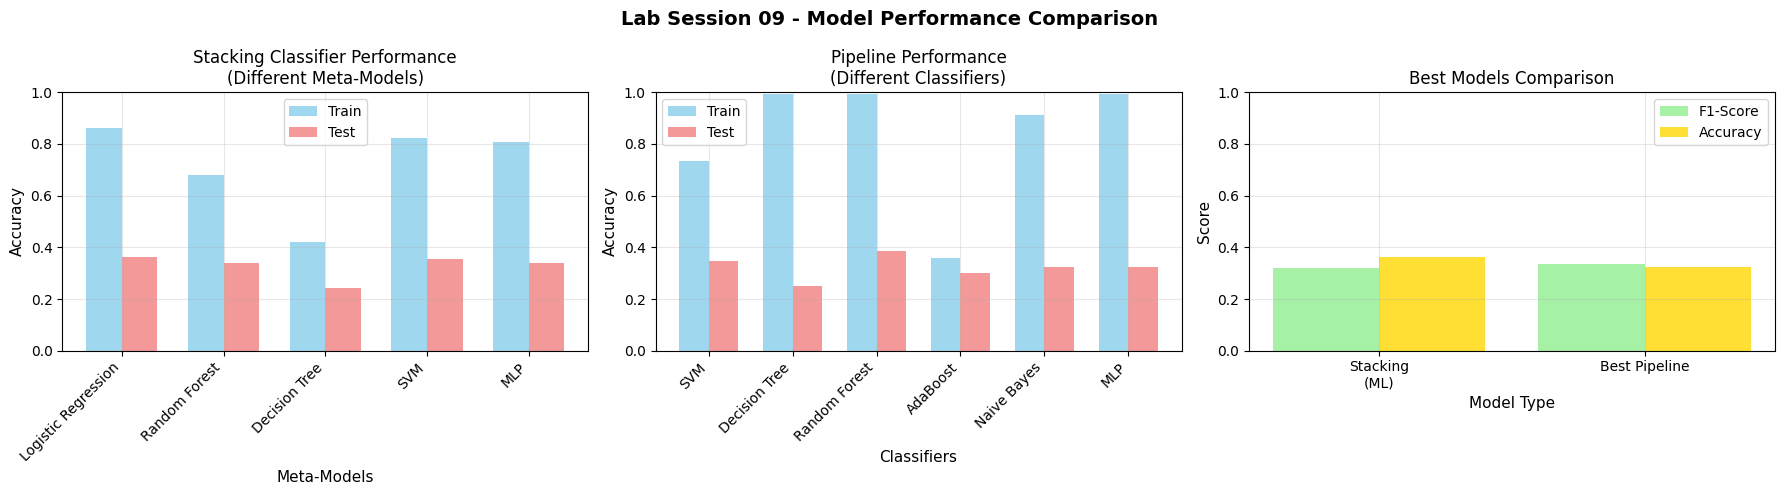


BEST PERFORMING MODELS:
Stacking Classifier: Logistic Regression
  - Test Accuracy: 0.3622
  - Test F1-Score: 0.3184

Best Pipeline: MLP
  - Test Accuracy: 0.3228
  - Test F1-Score: 0.3370


In [12]:
# Cell 8: Optional - Visualize and compare all models
def plot_model_comparison(stacking_results, pipeline_results):
    """
    Create comparison plots for all models
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Plot 1: Stacking Classifier Comparison
    ax1 = axes[0]
    x = np.arange(len(stacking_results['Meta-Model']))
    width = 0.35

    ax1.bar(x - width/2, stacking_results['Train Accuracy'], width, label='Train', alpha=0.8, color='skyblue')
    ax1.bar(x + width/2, stacking_results['Test Accuracy'], width, label='Test', alpha=0.8, color='lightcoral')
    ax1.set_xlabel('Meta-Models', fontsize=11)
    ax1.set_ylabel('Accuracy', fontsize=11)
    ax1.set_title('Stacking Classifier Performance\n(Different Meta-Models)', fontsize=12)
    ax1.set_xticks(x)
    ax1.set_xticklabels(stacking_results['Meta-Model'], rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 1])

    # Plot 2: Pipeline Comparison
    ax2 = axes[1]
    x2 = np.arange(len(pipeline_results['Pipeline Classifier']))

    bars1 = ax2.bar(x2 - width/2, pipeline_results['Train Accuracy'], width, label='Train', alpha=0.8, color='skyblue')
    bars2 = ax2.bar(x2 + width/2, pipeline_results['Test Accuracy'], width, label='Test', alpha=0.8, color='lightcoral')
    ax2.set_xlabel('Classifiers', fontsize=11)
    ax2.set_ylabel('Accuracy', fontsize=11)
    ax2.set_title('Pipeline Performance\n(Different Classifiers)', fontsize=12)
    ax2.set_xticks(x2)
    ax2.set_xticklabels(pipeline_results['Pipeline Classifier'], rotation=45, ha='right')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim([0, 1])

    # Plot 3: F1-Score Comparison
    ax3 = axes[2]
    # Get best models from each category
    best_stacking = stacking_results.loc[stacking_results['Test F1-Score'].idxmax()]
    best_pipeline = pipeline_results.loc[pipeline_results['Test F1-Score'].idxmax()]

    models = ['Stacking\n(ML)', 'Best Pipeline']
    f1_scores = [best_stacking['Test F1-Score'], best_pipeline['Test F1-Score']]
    accuracies = [best_stacking['Test Accuracy'], best_pipeline['Test Accuracy']]

    x3 = np.arange(len(models))
    ax3.bar(x3 - 0.2, f1_scores, 0.4, label='F1-Score', alpha=0.8, color='lightgreen')
    ax3.bar(x3 + 0.2, accuracies, 0.4, label='Accuracy', alpha=0.8, color='gold')
    ax3.set_xlabel('Model Type', fontsize=11)
    ax3.set_ylabel('Score', fontsize=11)
    ax3.set_title('Best Models Comparison', fontsize=12)
    ax3.set_xticks(x3)
    ax3.set_xticklabels(models)
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.set_ylim([0, 1])

    plt.suptitle('Lab Session 09 - Model Performance Comparison', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Print best models
    print("\n" + "="*50)
    print("BEST PERFORMING MODELS:")
    print("="*50)
    print(f"Stacking Classifier: {best_stacking['Meta-Model']}")
    print(f"  - Test Accuracy: {best_stacking['Test Accuracy']:.4f}")
    print(f"  - Test F1-Score: {best_stacking['Test F1-Score']:.4f}")
    print(f"\nBest Pipeline: {best_pipeline['Pipeline Classifier']}")
    print(f"  - Test Accuracy: {best_pipeline['Test Accuracy']:.4f}")
    print(f"  - Test F1-Score: {best_pipeline['Test F1-Score']:.4f}")

# Generate visualizations
print("\n📊 Generating comparison plots...")
plot_model_comparison(stacking_results, pipeline_results)